#### Import the libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

#### Load the dataset and add headers

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


#### Missing Values

In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

#### Duplicate Values

In [8]:
movies.duplicated().sum()

np.int64(0)

In [9]:
ratings.duplicated().sum()

np.int64(0)

#### Data Information

In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [11]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


#### Rating Distribution

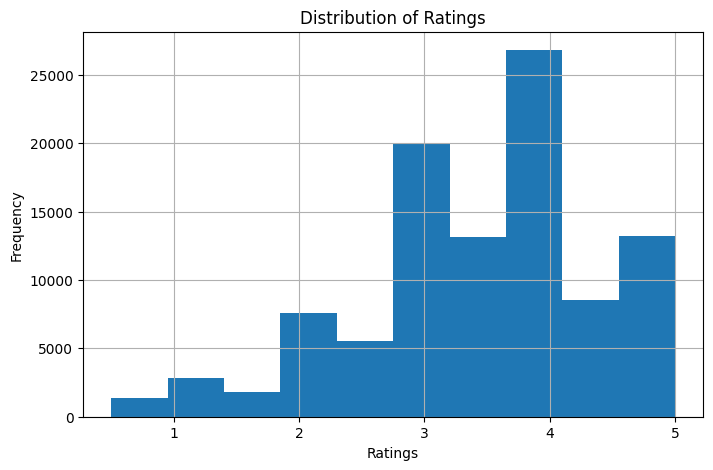

In [12]:
plt.figure(figsize=(8,5))

ratings['rating'].hist(bins=10)

plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.show()

#### Top Rated Movies

In [13]:
movie_stats = ratings.groupby('movieId').agg({
    'rating':['mean','count']
})

movie_stats.columns=['Average Rating','Number of Ratings']

movie_stats.reset_index(inplace=True)

movie_stats = movie_stats.merge(movies,on='movieId')

movie_stats.sort_values(
    'Average Rating',
    ascending=False
).head(10)

,movieId,Average Rating,Number of Ratings,title,genres
9693,187717,5.0,1,Won't You Be My Neighbor? (2018),Documentary
4667,6983,5.0,1,Jane Eyre (1944),Drama|Romance
3802,5328,5.0,1,Rain (2001),Drama|Romance
7927,95843,5.0,1,Goodbye Charlie (1964),Comedy|Fantasy|Romance
2934,3941,5.0,1,Sorority House Massacre (1986),Horror
2933,3940,5.0,1,Slumber Party Massacre III (1990),Horror
2932,3939,5.0,1,Slumber Party Massacre II (1987),Horror
5015,7815,5.0,1,True Stories (1986),Comedy|Musical
9349,162414,5.0,1,Moonlight,Drama
9347,162344,5.0,1,Tom Segura: Mostly Stories (2016),Comedy


#### Most Rated Movies

In [14]:
top_movies = ratings.groupby('movieId').size()

top_movies = top_movies.sort_values(
    ascending=False
).head(10)

top_movies = pd.DataFrame(top_movies)

top_movies.reset_index(inplace=True)

top_movies = top_movies.merge(movies,on='movieId')

top_movies

,movieId,0,title,genres
0,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
2,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,110,237,Braveheart (1995),Action|Drama|War
8,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
9,527,220,Schindler's List (1993),Drama|War


#### Merge Datasets

In [15]:
movie_data = pd.merge(
    ratings,
    movies,
    on='movieId'
)

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


#### Create User-Movie Matrix

In [16]:
user_movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

user_movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Fill Missing Ratings

In [17]:
user_movie_matrix = user_movie_matrix.fillna(0)

#### Matrix Shape

In [18]:
print(user_movie_matrix.shape)

(610, 9719)


#### Cosine Similarity

In [19]:
user_similarity = cosine_similarity(
    user_movie_matrix
)

print(user_similarity.shape)

(610, 610)


#### Convert into DataFrame

In [20]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


#### Find Similar Users

In [21]:
user_similarity_df.iloc[0].sort_values(
    ascending=False
).head(10)

userId
1      1.000000
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
469    0.330664
39     0.329782
288    0.329700
452    0.328048
Name: 1, dtype: float64

# Recommendation Function

In [22]:
def recommend_movies(user_id, n_recommendations=10):

    similar_users = user_similarity_df[user_id].sort_values(
        ascending=False
    )[1:11]

    weighted_ratings = pd.Series(dtype=float)

    for similar_user, similarity_score in similar_users.items():

        ratings = user_movie_matrix.loc[similar_user]

        weighted_ratings = weighted_ratings.add(
            ratings * similarity_score,
            fill_value=0
        )

    watched_movies = user_movie_matrix.loc[user_id]

    recommendations = weighted_ratings[
        watched_movies == 0
    ]

    recommendations = recommendations.sort_values(
        ascending=False
    )

    return recommendations.head(n_recommendations)

In [28]:
user_id = 9

recommend_movies(user_id, n_recommendations=5)

title
Matrix, The (1999)                                       6.345607
Lord of the Rings: The Return of the King, The (2003)    5.315422
Star Wars: Episode V - The Empire Strikes Back (1980)    4.812279
Star Wars: Episode IV - A New Hope (1977)                4.591579
Star Wars: Episode VI - Return of the Jedi (1983)        4.079432
dtype: float64

In [23]:
recommend_movies(1)

title
Terminator 2: Judgment Day (1991)    14.182299
Aliens (1986)                        13.925162
Sixth Sense, The (1999)              13.422015
Hunt for Red October, The (1990)     13.377867
Godfather, The (1972)                13.134550
2001: A Space Odyssey (1968)         13.031035
Die Hard (1988)                      12.862273
Blade Runner (1982)                  12.539779
Godfather: Part II, The (1974)       12.104995
Breakfast Club, The (1985)           12.080897
dtype: float64

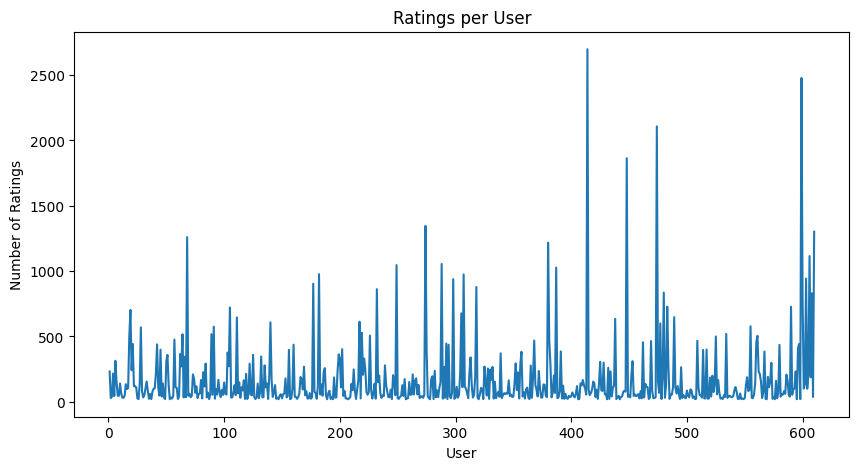

In [24]:
ratings_per_user = ratings.groupby(
    'userId'
).size()

plt.figure(figsize=(10,5))

ratings_per_user.plot()

plt.title("Ratings per User")

plt.xlabel("User")

plt.ylabel("Number of Ratings")

plt.show()

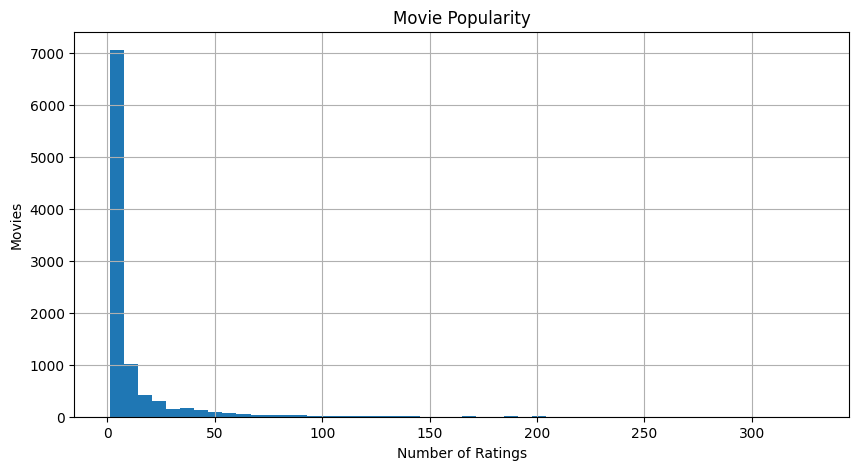

In [25]:
movie_popularity = ratings.groupby(
    'movieId'
).size()

plt.figure(figsize=(10,5))

movie_popularity.hist(bins=50)

plt.title("Movie Popularity")

plt.xlabel("Number of Ratings")

plt.ylabel("Movies")

plt.show()

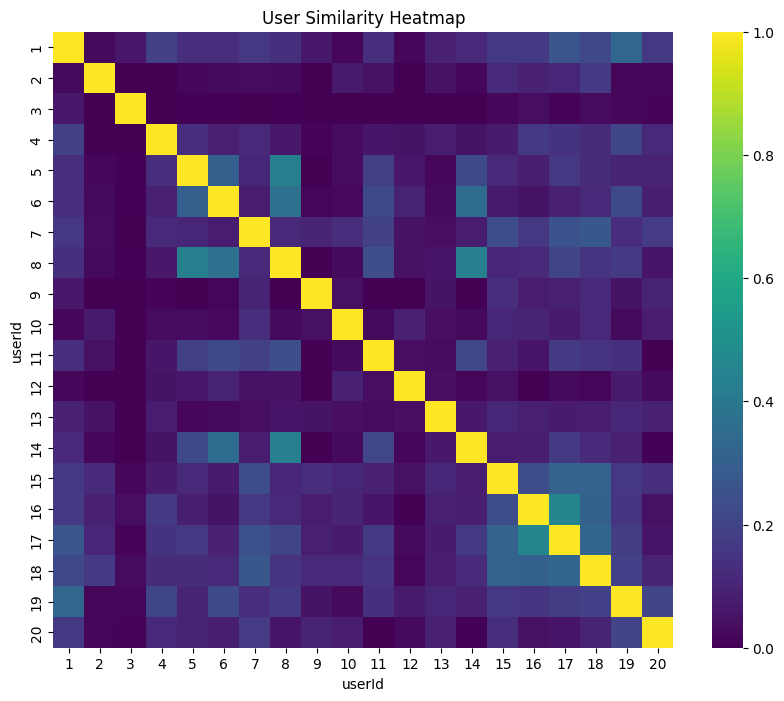

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    user_similarity_df.iloc[:20,:20],
    cmap='viridis'
)

plt.title("User Similarity Heatmap")

plt.show()